# Quantitative Evaluation Analysis

Analysis notebook for the quantitative evaluation and practical pipeline performance metrics.

Used to fill the quantitative replication package Excel sheet. 


In [1]:
from pathlib import Path
import hashlib
import itertools
import json
import math
import re
import statistics

import pandas as pd

pd.set_option('display.max_columns', 80)
pd.set_option('display.max_colwidth', 120)

def find_repo_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / "pipeline").exists() and (candidate / "evaluation").exists():
            return candidate
    raise RuntimeError("Could not locate replication package root.")

REPO_ROOT = find_repo_root(Path.cwd().resolve())
MEASUREMENT_ROOT = REPO_ROOT / 'evaluation/runs/final_runs/20260606-091359'
EXCEL_PATH = REPO_ROOT / 'evaluation/quantitative_analysis/all_runs_results.xlsx'

DATASET_ORDER = [
    'Camperplus',
    'Fish&Chips',
    'Grocery',
    'Sports',
    'Education',
    'Collaboration',
    'Cinema',
    'Matching',
    'Brewery',
]

STABILITY_ROOT = MEASUREMENT_ROOT / 'all_runs'
INPUT_ROOT = MEASUREMENT_ROOT / 'run_inputs'

print('Measurement root:', MEASUREMENT_ROOT)
print('Stability root exists:', STABILITY_ROOT.exists())
print('Excel workbook exists:', EXCEL_PATH.exists())

Measurement root: /Users/matthiaslouws/Documents/Repositories/us2lc-pipeline-replication/evaluation/runs/final_runs/20260606-091359
Stability root exists: True
Excel workbook exists: True


## Helper Functions

In [2]:
def read_json(path):
    path = Path(path)
    if not path.exists():
        return None
    try:
        return json.loads(path.read_text(encoding='utf-8'))
    except json.JSONDecodeError:
        return None


def read_text(path):
    path = Path(path)
    return path.read_text(encoding='utf-8', errors='replace') if path.exists() else ''


def specs(section):
    if isinstance(section, list):
        return section
    if isinstance(section, dict) and isinstance(section.get('specs'), list):
        return section['specs']
    return []


def safe_list(value):
    return value if isinstance(value, list) else []


def ns_to_s(value):
    try:
        return float(value) / 1_000_000_000
    except (TypeError, ValueError):
        return None


def ms_to_s(value):
    try:
        return float(value) / 1000
    except (TypeError, ValueError):
        return None


def number_or_none(value):
    if value is None or pd.isna(value):
        return None
    text = str(value).strip()
    if not text or text.lower() in {'n/a', 'na', 'none', 'nan'}:
        return None
    try:
        return float(text)
    except ValueError:
        return None


def mean_or_none(values):
    values = [float(value) for value in values if value is not None and not pd.isna(value)]
    return sum(values) / len(values) if values else None


def sd_or_none(values):
    values = [float(value) for value in values if value is not None and not pd.isna(value)]
    return statistics.stdev(values) if len(values) > 1 else 0 if len(values) == 1 else None


def population_variance(values):
    values = [float(value) for value in values if value is not None and not pd.isna(value)]
    if len(values) <= 1:
        return 0 if len(values) == 1 else None
    avg = sum(values) / len(values)
    return sum((value - avg) ** 2 for value in values) / len(values)


def coefficient_of_variation(values):
    values = [float(value) for value in values if value is not None and not pd.isna(value)]
    if not values:
        return None
    avg = sum(values) / len(values)
    if avg == 0:
        return 0.0 if all(value == 0 for value in values) else None
    return sd_or_none(values) / avg


def stable(value):
    volatile_keys = {'generatedAt', 'startedAt', 'finishedAt'}
    if isinstance(value, list):
        return [stable(item) for item in value]
    if isinstance(value, dict):
        return {key: stable(value[key]) for key in sorted(value) if key not in volatile_keys}
    return value


def normalize_plan(plan):
    normalized = stable(plan or {})
    domain = normalized.get('domainModel') or {}
    domain['entities'] = sorted(safe_list(domain.get('entities')), key=lambda item: str(item.get('name', '')))
    domain['associations'] = sorted(
        safe_list(domain.get('associations')),
        key=lambda item: tuple(str(item.get(key, '')) for key in ('parentEntity', 'childEntity', 'name')),
    )
    domain['enumerations'] = sorted(safe_list(domain.get('enumerations')), key=lambda item: str(item.get('name', '')))
    if domain:
        normalized['domainModel'] = domain

    for section in ('pages', 'microflows', 'nanoflows', 'workflows'):
        value = normalized.get(section)
        if isinstance(value, dict) and isinstance(value.get('specs'), list):
            value['specs'] = sorted(value['specs'], key=lambda item: str(item.get('ref') or item.get('name') or ''))

    security = normalized.get('security')
    if isinstance(security, dict):
        for key in ('moduleRoles', 'userRoles'):
            if isinstance(security.get(key), list):
                security[key] = sorted(
                    security[key],
                    key=lambda item: str(item.get('name', '')) if isinstance(item, dict) else str(item),
                )
    return normalized


def fingerprint(value):
    payload = json.dumps(stable(value), sort_keys=True, separators=(',', ':'))
    return hashlib.sha1(payload.encode('utf-8')).hexdigest()


def jaccard(left, right):
    left = set(item for item in left if item)
    right = set(item for item in right if item)
    union = left | right
    return 1.0 if not union else len(left & right) / len(union)


def parse_progress_times(stderr_text):
    rows = []
    for line in str(stderr_text or '').splitlines():
        match = re.search(r'\[generate:plan \+(\d+(?:\.\d+)?)s\]\s*(.*)', line)
        if match:
            rows.append({'time_s': float(match.group(1)), 'message': match.group(2)})
    return rows


def infer_stage_delta(progress_rows, start_contains, end_contains):
    start = None
    end = None
    for row in progress_rows:
        if start is None and start_contains in row['message']:
            start = row['time_s']
        if start is not None and end_contains in row['message']:
            end = row['time_s']
            break
    if start is None or end is None:
        return None
    return max(0, end - start)


def stage_duration_map(progress_rows):
    starts = {}
    stage_times = []
    for row in progress_rows:
        match = re.search(r'^Stage (\d+)/10:', row['message'])
        if match:
            stage = int(match.group(1))
            stage_times.append((stage, row['time_s']))
            starts.setdefault(stage, row['time_s'])
    durations = {}
    for stage in range(1, 11):
        start = starts.get(stage)
        if start is None:
            durations[f'stage_{stage}_duration_s'] = None
            continue
        next_times = [time_s for next_stage, time_s in stage_times if next_stage > stage]
        if next_times:
            durations[f'stage_{stage}_duration_s'] = max(0, min(next_times) - start)
        else:
            durations[f'stage_{stage}_duration_s'] = max(0, progress_rows[-1]['time_s'] - start) if progress_rows else None
    return durations


def load_manual_mendix_metrics(path):
    if not path.exists():
        return {}
    try:
        manual_df = pd.read_excel(path, sheet_name='all_runs')
    except (FileNotFoundError, ValueError):
        return {}
    required = {'dataset', 'run_id', 'mendix_error_count'}
    if not required.issubset(manual_df.columns):
        return {}
    metrics = {}
    for _, row in manual_df.iterrows():
        key = (str(row.get('dataset') or '').strip(), str(row.get('run_id') or '').strip())
        if not all(key):
            continue
        metrics[key] = {
            'mendix_app_created': row.get('mendix_app_created') if 'mendix_app_created' in manual_df.columns else None,
            'mendix_error_count': number_or_none(row.get('mendix_error_count')),
        }
    return metrics

In [3]:
def artifact_counts(plan):
    plan = plan or {}
    domain = plan.get('domainModel') or {}
    entities = safe_list(domain.get('entities'))
    associations = safe_list(domain.get('associations'))
    enumerations = safe_list(domain.get('enumerations'))
    pages = specs(plan.get('pages'))
    microflows = specs(plan.get('microflows'))
    nanoflows = specs(plan.get('nanoflows'))
    workflows = specs(plan.get('workflows'))
    security = plan.get('security') or {}
    security_roles = max(len(safe_list(security.get('moduleRoles'))), len(safe_list(security.get('userRoles'))))
    attributes = sum(len(safe_list(entity.get('attributes'))) for entity in entities if isinstance(entity, dict))
    generated_artifact_count = (
        len(entities) + attributes + len(associations) + len(enumerations) + len(pages) +
        len(microflows) + len(nanoflows) + len(workflows) + security_roles
    )
    return {
        'entity_count': len(entities),
        'attribute_count': attributes,
        'association_count': len(associations),
        'enumeration_count': len(enumerations),
        'page_count': len(pages),
        'microflow_count': len(microflows),
        'nanoflow_count': len(nanoflows),
        'workflow_count': len(workflows),
        'security_role_count': security_roles,
        'generated_artifact_count': generated_artifact_count,
    }


def normalize_entity_ref(value):
    text = str(value or '').strip()
    return text.split('.')[-1] if text else ''


def is_allowed_external_entity_ref(value):
    text = str(value or '').strip()
    return text.startswith('System.') or text.startswith('Administration.')


def walk_page_steps(steps):
    for step in safe_list(steps):
        if not isinstance(step, dict):
            continue
        yield step
        for key in ('content', 'templateContent', 'itemContent', 'columns'):
            yield from walk_page_steps(step.get(key))


def reference_integrity(plan):
    plan = plan or {}
    module_name = str((plan.get('app') or {}).get('moduleName') or '').strip()
    pages = specs(plan.get('pages'))
    page_refs = set()
    for page in pages:
        if isinstance(page, dict):
            page_refs.update(value for value in [page.get('ref'), page.get('name')] if isinstance(value, str) and value)

    entity_refs = set()
    for entity in safe_list((plan.get('domainModel') or {}).get('entities')):
        if not isinstance(entity, dict):
            continue
        name = str(entity.get('name') or '').strip()
        if name:
            entity_refs.add(name)
            if module_name:
                entity_refs.add(f'{module_name}.{name}')

    microflow_refs = set()
    for flow in specs(plan.get('microflows')):
        if isinstance(flow, dict):
            microflow_refs.update(value for value in [flow.get('ref'), flow.get('name')] if isinstance(value, str) and value)

    workflow_refs = set()
    for flow in specs(plan.get('workflows')):
        if isinstance(flow, dict):
            workflow_refs.update(value for value in [flow.get('ref'), flow.get('name')] if isinstance(value, str) and value)

    checks = []

    def add_check(location, reference_type, target, valid):
        if target is None or target == '':
            return
        checks.append({
            'location': location,
            'reference_type': reference_type,
            'target': target,
            'valid': bool(valid),
        })

    for page in pages:
        if not isinstance(page, dict):
            continue
        page_id = page.get('ref') or page.get('name') or 'unknown'
        page_entity_ref = page.get('entityRef')
        add_check(
            f'pages.{page_id}.entityRef',
            'page_entity_ref',
            page_entity_ref,
            page_entity_ref in entity_refs or is_allowed_external_entity_ref(page_entity_ref),
        )
        for step in walk_page_steps(page.get('content')):
            step_type = step.get('type') or 'step'
            location = f'pages.{page_id}.{step_type}'
            add_check(location, 'page_ref', step.get('pageRef'), step.get('pageRef') in page_refs)
            add_check(location, 'target_page_ref', step.get('targetPageRef'), step.get('targetPageRef') in page_refs)
            add_check(location, 'row_click_target_page_ref', step.get('rowClickTargetPageRef'), step.get('rowClickTargetPageRef') in page_refs)
            add_check(location, 'microflow_ref', step.get('microflowRef'), step.get('microflowRef') in microflow_refs)
            add_check(location, 'workflow_ref', step.get('workflowRef'), step.get('workflowRef') in workflow_refs)
            step_entity_ref = step.get('entityRef')
            add_check(
                location,
                'step_entity_ref',
                step_entity_ref,
                step_entity_ref in entity_refs or is_allowed_external_entity_ref(step_entity_ref),
            )

    navigation = (plan.get('app') or {}).get('navigation') or {}
    nav_entries = []
    if isinstance(navigation, dict):
        nav_entries.extend(safe_list(navigation.get('homePageButtons')))
        nav_entries.extend(safe_list(navigation.get('menuItems')))
    for i, entry in enumerate(nav_entries, start=1):
        if isinstance(entry, dict):
            add_check(f'app.navigation[{i}].pageRef', 'navigation_page_ref', entry.get('pageRef'), entry.get('pageRef') in page_refs)

    broken = [check for check in checks if not check['valid']]
    return {
        'reference_integrity_ok': len(broken) == 0,
        'checked_reference_count': len(checks),
        'broken_reference_count': len(broken),
        'reference_integrity_issue_rate': (len(broken) / len(checks)) if checks else 0,
        'checks': checks,
        'issues': broken,
    }


def warning_category(message):
    text = str(message or '').lower()
    if 'dropped association' in text:
        return 'dropped_association'
    if 'dropped low-relevance' in text:
        return 'dropped_low_relevance'
    if 'dropped placeholder page' in text:
        return 'dropped_placeholder_page'
    if 'added missing' in text:
        return 'added_missing_artifact'
    if 'repaired' in text:
        return 'repaired_artifact'
    if 'domain review' in text:
        return 'domain_review'
    if 'process visualizer' in text:
        return 'process_visualizer'
    if 'visual narrator' in text:
        return 'visual_narrator'
    return 'other'


def plan_shape(plan):
    plan = plan or {}
    domain = plan.get('domainModel') or {}
    entities = {entity.get('name') for entity in safe_list(domain.get('entities')) if isinstance(entity, dict)}
    associations = set()
    for assoc in safe_list(domain.get('associations')):
        if isinstance(assoc, dict):
            associations.add('->'.join(str(assoc.get(key, '')) for key in ('parentEntity', 'childEntity', 'name')))
    pages = {page.get('ref') or page.get('name') for page in specs(plan.get('pages')) if isinstance(page, dict)}
    flows = set()
    for section in ('microflows', 'nanoflows', 'workflows'):
        for flow in specs(plan.get(section)):
            if isinstance(flow, dict):
                flows.add(flow.get('ref') or flow.get('name'))
    page_step_types = {
        step.get('type')
        for page in specs(plan.get('pages'))
        if isinstance(page, dict)
        for step in walk_page_steps(page.get('content'))
        if step.get('type')
    }
    return {
        'fingerprint': fingerprint(normalize_plan(plan)),
        'entities': entities,
        'associations': associations,
        'pages': pages,
        'flows': flows,
        'page_step_types': page_step_types,
        'counts': artifact_counts(plan),
    }

## Load All Runs

In [4]:
run_records = []
warning_records = []
story_records = []
reference_records = []
run_objects = {}
manual_mendix_metrics = load_manual_mendix_metrics(EXCEL_PATH)

for dataset in DATASET_ORDER:
    dataset_dir = STABILITY_ROOT / dataset
    if not dataset_dir.exists():
        print('Missing dataset dir:', dataset_dir)
        continue
    for run_dir in sorted(path for path in dataset_dir.glob('run-*') if path.is_dir()):
        run_id = run_dir.name
        plan = read_json(run_dir / 'plan.json')
        report = read_json(run_dir / 'generation-report.json') or {}
        stderr_text = read_text(run_dir / 'stderr.log')
        stdout_text = read_text(run_dir / 'stdout.log')
        progress_rows = parse_progress_times(stderr_text)
        counts = artifact_counts(plan)
        coverage = report.get('coverage') or {}
        validation = report.get('validation') or {}
        ollama = report.get('ollama') or {}
        total_time_s = max([row['time_s'] for row in progress_rows], default=None)
        stage_duration_fields = stage_duration_map(progress_rows)
        manual_mendix = manual_mendix_metrics.get((dataset, run_id), {})
        mendix_error_count = manual_mendix.get('mendix_error_count')
        record = {
            'dataset': dataset,
            'run_id': run_id,
            'validation_passed': bool(validation.get('ok')),
            'mendix_app_created': manual_mendix.get('mendix_app_created'),
            'total_end_to_end_time_s': total_time_s,
            **counts,
            'mendix_error_count': mendix_error_count,
            'mendix_error_rate': (mendix_error_count / counts['generated_artifact_count']) if mendix_error_count is not None and counts['generated_artifact_count'] else None,
            **stage_duration_fields,
            'notes': '',
            'coverage_score': coverage.get('score'),
            'coverage_covered': coverage.get('covered'),
            'coverage_total': coverage.get('total'),
            'missing_story_count': len(coverage.get('missingStoryIds') or []),
            'warning_count': len(report.get('warnings') or []),
            'model': report.get('model'),
            'prompt_tokens': ollama.get('promptEvalCount'),
            'output_tokens': ollama.get('evalCount'),
            'tokens_per_second': (ollama.get('evalCount') / stage_duration_fields.get('stage_5_duration_s')) if stage_duration_fields.get('stage_5_duration_s') else None,
            'plan_path': str(run_dir / 'plan.json'),
            'report_path': str(run_dir / 'generation-report.json'),
        }
        run_records.append(record)
        run_objects[(dataset, run_id)] = {
            'plan': plan,
            'report': report,
            'stderr': stderr_text,
            'stdout': stdout_text,
            'progress': progress_rows,
            'shape': plan_shape(plan),
        }

        for warning in report.get('warnings') or []:
            warning_records.append({
                'dataset': dataset,
                'run_id': run_id,
                'category': warning_category(warning),
                'warning': warning,
            })

        for entry in coverage.get('entries') or []:
            story_records.append({
                'dataset': dataset,
                'run_id': run_id,
                'story_id': entry.get('id'),
                'covered': bool(entry.get('covered')),
                'lexical_score': entry.get('lexicalScore'),
                'matched_concepts': ', '.join(entry.get('matchedConcepts') or []),
                'story': entry.get('story'),
            })
all_runs_df = pd.DataFrame(run_records)
warning_details_df = pd.DataFrame(warning_records)
story_coverage_df = pd.DataFrame(story_records)
reference_integrity_details_df = pd.DataFrame(reference_records)

all_runs_df



Missing dataset dir: /Users/matthiaslouws/Documents/Repositories/us2lc-pipeline-replication/evaluation/runs/final_runs/20260606-091359/all_runs/Fish&Chips


,dataset,run_id,validation_passed,mendix_app_created,total_end_to_end_time_s,entity_count,attribute_count,association_count,enumeration_count,page_count,microflow_count,nanoflow_count,workflow_count,security_role_count,generated_artifact_count,mendix_error_count,mendix_error_rate,stage_1_duration_s,stage_2_duration_s,stage_3_duration_s,stage_4_duration_s,stage_5_duration_s,stage_6_duration_s,stage_7_duration_s,stage_8_duration_s,stage_9_duration_s,stage_10_duration_s,notes,coverage_score,coverage_covered,coverage_total,missing_story_count,warning_count,model,prompt_tokens,output_tokens,tokens_per_second,plan_path,report_path
0,Camperplus,run-01,True,True,845.3,30,62,12,0,69,3,1,0,4,181,2.0,0.011050,0.0,0.0,0.0,0.0,34.1,456.8,184.1,170.3,0.0,0.0,,0.690909,38,55,17,178,llama3.3:70b,5525,418,12.258065,/Users/matthiaslouws/Documents/Repositories/us2lc-pipeline-replication/evaluation/runs/final_runs/20260606-091359/al...,/Users/matthiaslouws/Documents/Repositories/us2lc-pipeline-replication/evaluation/runs/final_runs/20260606-091359/al...
1,Camperplus,run-04,True,True,800.9,30,62,12,0,67,3,1,0,4,179,2.0,0.011173,0.0,0.0,0.0,0.0,33.7,458.5,175.5,133.2,0.0,0.0,,0.690909,38,55,17,176,llama3.3:70b,5525,418,12.403561,/Users/matthiaslouws/Documents/Repositories/us2lc-pipeline-replication/evaluation/runs/final_runs/20260606-091359/al...,/Users/matthiaslouws/Documents/Repositories/us2lc-pipeline-replication/evaluation/runs/final_runs/20260606-091359/al...
2,Camperplus,run-05,True,True,809.5,29,60,13,0,67,3,1,0,4,177,2.0,0.011299,0.0,0.0,0.0,0.0,33.8,459.2,148.5,167.9,0.1,0.0,,0.600000,33,55,22,186,llama3.3:70b,5525,418,12.366864,/Users/matthiaslouws/Documents/Repositories/us2lc-pipeline-replication/evaluation/runs/final_runs/20260606-091359/al...,/Users/matthiaslouws/Documents/Repositories/us2lc-pipeline-replication/evaluation/runs/final_runs/20260606-091359/al...
3,Grocery,run-01,True,False,778.4,20,54,11,2,50,3,1,0,4,145,NaN,NaN,0.0,0.0,0.0,0.0,25.2,441.6,154.0,157.5,0.1,0.0,,0.469388,23,49,26,156,llama3.3:70b,5659,287,11.388889,/Users/matthiaslouws/Documents/Repositories/us2lc-pipeline-replication/evaluation/runs/final_runs/20260606-091359/al...,/Users/matthiaslouws/Documents/Repositories/us2lc-pipeline-replication/evaluation/runs/final_runs/20260606-091359/al...
4,Grocery,run-04,True,True,742.2,30,65,0,2,66,3,1,0,4,171,0.0,0.000000,0.0,0.0,0.0,0.0,25.2,449.9,140.0,127.0,0.1,0.0,,0.530612,26,49,23,179,llama3.3:70b,5659,287,11.388889,/Users/matthiaslouws/Documents/Repositories/us2lc-pipeline-replication/evaluation/runs/final_runs/20260606-091359/al...,/Users/matthiaslouws/Documents/Repositories/us2lc-pipeline-replication/evaluation/runs/final_runs/20260606-091359/al...
5,Grocery,run-05,True,True,844.3,31,70,0,2,72,5,2,0,4,186,0.0,0.000000,0.0,0.0,0.0,0.0,25.6,523.6,127.9,167.1,0.1,0.0,,0.489796,24,49,25,196,llama3.3:70b,5659,287,11.210938,/Users/matthiaslouws/Documents/Repositories/us2lc-pipeline-replication/evaluation/runs/final_runs/20260606-091359/al...,/Users/matthiaslouws/Documents/Repositories/us2lc-pipeline-replication/evaluation/runs/final_runs/20260606-091359/al...
6,Sports,run-01,True,True,862.4,24,54,11,2,57,5,2,0,6,161,4.0,0.024845,0.0,0.0,0.0,0.0,40.6,487.9,135.4,198.5,0.0,0.0,,0.619048,39,63,24,181,llama3.3:70b,5722,524,12.906404,/Users/matthiaslouws/Documents/Repositories/us2lc-pipeline-replication/evaluation/runs/final_runs/20260606-091359/al...,/Users/matthiaslouws/Documents/Repositories/us2lc-pipeline-replication/evaluation/runs/final_runs/20260606-091359/al...
7,Sports,run-04,True,True,825.5,24,56,11,1,59,3,1,0,6,161,1.0,0.006211,0.0,0.0,0.0,0.0,39.6,489.2,135.3,161.3,0.1,0.0,,0.619048,39,63,24,186,llama3.3:70b,5722,506,12.777778,/Users/matthiaslouws/Documents/Repositories/us2lc-pipeline-replication/evaluation/runs/final_runs/20260606-091359/al...,/Users/matthiaslouws/Documents/Repositories/us2lc-pipeline-replication/evaluation/runs/final_runs/20260606-091359/al...
8,Sports,run-05,True,True,799.8,23,50,12,0,57,3,1,0,7,

## `all_runs` 

In [5]:
all_runs_columns = [
    'dataset', 'run_id', 'validation_passed', 'mendix_app_created',
    'total_end_to_end_time_s',
    'entity_count', 'attribute_count', 'association_count',
    'enumeration_count', 'page_count', 'microflow_count', 
    'nanoflow_count', 'workflow_count',
    'security_role_count', 'generated_artifact_count',
    'mendix_error_count', 'mendix_error_rate',
    'coverage_score', 'coverage_covered', 'coverage_total',
    'missing_story_count', 'warning_count', 'model',
    'prompt_tokens', 'output_tokens', 'tokens_per_second',
    'stage_1_duration_s', 'stage_2_duration_s', 'stage_3_duration_s', 'stage_4_duration_s',
    'stage_5_duration_s', 'stage_6_duration_s', 'stage_7_duration_s', 'stage_8_duration_s',
    'stage_9_duration_s', 'stage_10_duration_s', 'notes'
]
all_runs_helper_df = all_runs_df[all_runs_columns].copy()
all_runs_helper_df



,dataset,run_id,validation_passed,mendix_app_created,total_end_to_end_time_s,entity_count,attribute_count,association_count,enumeration_count,page_count,microflow_count,nanoflow_count,workflow_count,security_role_count,generated_artifact_count,mendix_error_count,mendix_error_rate,coverage_score,coverage_covered,coverage_total,missing_story_count,warning_count,model,prompt_tokens,output_tokens,tokens_per_second,stage_1_duration_s,stage_2_duration_s,stage_3_duration_s,stage_4_duration_s,stage_5_duration_s,stage_6_duration_s,stage_7_duration_s,stage_8_duration_s,stage_9_duration_s,stage_10_duration_s,notes
0,Camperplus,run-01,True,True,845.3,30,62,12,0,69,3,1,0,4,181,2.0,0.011050,0.690909,38,55,17,178,llama3.3:70b,5525,418,12.258065,0.0,0.0,0.0,0.0,34.1,456.8,184.1,170.3,0.0,0.0,
1,Camperplus,run-04,True,True,800.9,30,62,12,0,67,3,1,0,4,179,2.0,0.011173,0.690909,38,55,17,176,llama3.3:70b,5525,418,12.403561,0.0,0.0,0.0,0.0,33.7,458.5,175.5,133.2,0.0,0.0,
2,Camperplus,run-05,True,True,809.5,29,60,13,0,67,3,1,0,4,177,2.0,0.011299,0.600000,33,55,22,186,llama3.3:70b,5525,418,12.366864,0.0,0.0,0.0,0.0,33.8,459.2,148.5,167.9,0.1,0.0,
3,Grocery,run-01,True,False,778.4,20,54,11,2,50,3,1,0,4,145,NaN,NaN,0.469388,23,49,26,156,llama3.3:70b,5659,287,11.388889,0.0,0.0,0.0,0.0,25.2,441.6,154.0,157.5,0.1,0.0,
4,Grocery,run-04,True,True,742.2,30,65,0,2,66,3,1,0,4,171,0.0,0.000000,0.530612,26,49,23,179,llama3.3:70b,5659,287,11.388889,0.0,0.0,0.0,0.0,25.2,449.9,140.0,127.0,0.1,0.0,
5,Grocery,run-05,True,True,844.3,31,70,0,2,72,5,2,0,4,186,0.0,0.000000,0.489796,24,49,25,196,llama3.3:70b,5659,287,11.210938,0.0,0.0,0.0,0.0,25.6,523.6,127.9,167.1,0.1,0.0,
6,Sports,run-01,True,True,862.4,24,54,11,2,57,5,2,0,6,161,4.0,0.024845,0.619048,39,63,24,181,llama3.3:70b,5722,524,12.906404,0.0,0.0,0.0,0.0,40.6,487.9,135.4,198.5,0.0,0.0,
7,Sports,run-04,True,True,825.5,24,56,11,1,59,3,1,0,6,161,1.0,0.006211,0.619048,39,63,24,186,llama3.3:70b,5722,506,12.777778,0.0,0.0,0.0,0.0,39.6,489.2,135.3,161.3,0.1,0.0,
8,Sports,run-05,True,True,799.8,23,50,12,0,57,3,1,0,7,153,3.0,0.019608,0.682540,43,63,20,179,llama3.3:70b,5722,448,12.479109,0.0,0.0,0.0,0.0,35.9,489.0,130.9,144.0,0.0,0.0,
9,Education,run-01,True,True,830.9,26,52,13,0,58,6,1,1,3,160,2.0,0.012500,0.666667,30,45,15,145,llama3.3:70b,5448,484,10.637363,0.0,0.0,0.0,0.1,45.5,326.8,274.7,183.8,0.0,0.0,


## `dataset_summary`

In [6]:
summary_rows = []
for dataset, group in all_runs_df.groupby('dataset', sort=False):
    best = group.sort_values(
        by=['validation_passed', 'coverage_score', 'total_end_to_end_time_s'],
        ascending=[False, False, True],
        na_position='last'
    ).iloc[0]
    summary_rows.append({
        'dataset': dataset,
        'run_count': len(group),
        'validation_pass_rate': mean_or_none(group['validation_passed']),
        'mendix_app_created_rate': mean_or_none(group['mendix_app_created']),
        'mean_total_time_s': mean_or_none(group['total_end_to_end_time_s']),
        'sd_total_time_s': sd_or_none(group['total_end_to_end_time_s']),
        'min_total_time_s': group['total_end_to_end_time_s'].min(),
        'max_total_time_s': group['total_end_to_end_time_s'].max(),
        'mean_entity_count': mean_or_none(group['entity_count']),
        'mean_attribute_count': mean_or_none(group['attribute_count']),
        'mean_association_count': mean_or_none(group['association_count']),
        'mean_enumeration_count': mean_or_none(group['enumeration_count']),
        'mean_page_count': mean_or_none(group['page_count']),
        'mean_microflow_count': mean_or_none(group['microflow_count']),
        'mean_nanoflow_count': mean_or_none(group['nanoflow_count']),
        'mean_workflow_count': mean_or_none(group['workflow_count']),
        'mean_security_role_count': mean_or_none(group['security_role_count']),
        'mean_generated_artifacts': mean_or_none(group['generated_artifact_count']),
        'sd_generated_artifacts': sd_or_none(group['generated_artifact_count']),
        'mean_mendix_errors': mean_or_none(group['mendix_error_count']),
        'mean_mendix_error_rate': mean_or_none(group['mendix_error_rate']),
        'best_run_id': best['run_id'],
        'mean_coverage_score': mean_or_none(group['coverage_score']),
        'mean_coverage_covered': mean_or_none(group['coverage_covered']),
        'mean_coverage_total': mean_or_none(group['coverage_total']),
        'mean_missing_story_count': mean_or_none(group['missing_story_count']),
        'mean_warning_count': mean_or_none(group['warning_count']),
        'mean_prompt_tokens': mean_or_none(group['prompt_tokens']),
        'mean_output_tokens': mean_or_none(group['output_tokens']),
        'mean_tokens_per_second': mean_or_none(group['tokens_per_second']),
        'summary_notes': ''
    })

dataset_summary_df = pd.DataFrame(summary_rows)
dataset_summary_df



,dataset,run_count,validation_pass_rate,mendix_app_created_rate,mean_total_time_s,sd_total_time_s,min_total_time_s,max_total_time_s,mean_entity_count,mean_attribute_count,mean_association_count,mean_enumeration_count,mean_page_count,mean_microflow_count,mean_nanoflow_count,mean_workflow_count,mean_security_role_count,mean_generated_artifacts,sd_generated_artifacts,mean_mendix_errors,mean_mendix_error_rate,best_run_id,mean_coverage_score,mean_coverage_covered,mean_coverage_total,mean_missing_story_count,mean_warning_count,mean_prompt_tokens,mean_output_tokens,mean_tokens_per_second,summary_notes
0,Camperplus,3,1.0,1.000000,818.566667,23.547682,800.9,845.3,29.666667,61.333333,12.333333,0.000000,67.666667,3.000000,1.000000,0.0,4.000000,179.000000,2.000000,2.000000,0.011174,run-04,0.660606,36.333333,55.0,18.666667,180.000000,5525.0,418.000000,12.342830,
1,Grocery,3,1.0,0.666667,788.300000,51.764950,742.2,844.3,27.000000,63.000000,3.666667,2.000000,62.666667,3.666667,1.333333,0.0,4.000000,167.333333,20.744477,0.000000,0.000000,run-04,0.496599,24.333333,49.0,24.666667,177.000000,5659.0,287.000000,11.329572,
2,Sports,3,1.0,1.000000,829.233333,31.466543,799.8,862.4,23.666667,53.333333,11.333333,1.000000,57.666667,3.666667,1.333333,0.0,6.333333,158.333333,4.618802,2.666667,0.016888,run-05,0.640212,40.333333,63.0,22.666667,182.000000,5722.0,492.666667,12.721097,
3,Education,3,1.0,1.000000,830.400000,29.053227,801.1,859.2,26.666667,52.333333,7.666667,0.000000,57.333333,6.666667,1.000000,1.0,3.000000,155.666667,3.785939,1.333333,0.008524,run-03,0.696296,31.333333,45.0,13.666667,161.000000,5448.0,484.000000,11.970562,
4,Collaboration,3,1.0,1.000000,787.900000,24.918266,761.3,810.7,22.000000,51.666667,10.333333,0.000000,67.333333,5.000000,2.000000,0.0,4.666667,163.000000,10.148892,0.000000,0.000000,run-01,0.877193,50.000000,57.0,7.000000,155.666667,5914.0,306.666667,10.604837,
5,Cinema,3,1.0,1.000000,867.866667,19.299309,845.9,882.1,26.000000,61.000000,1.000000,0.000000,67.666667,3.333333,1.333333,0.0,4.000000,164.333333,2.081666,2.000000,0.012172,run-07,0.837398,68.666667,82.0,13.333333,175.000000,7599.0,446.666667,11.784225,
6,Matching,3,1.0,1.000000,831.600000,26.873593,801.1,851.8,28.333333,65.666667,7.666667,1.000000,66.000000,3.000000,1.333333,0.0,3.000000,176.000000,10.392305,0.000000,0.000000,run-01,0.802721,39.333333,49.0,9.666667,193.666667,4852.0,442.000000,12.926018,
7,Brewery,3,1.0,1.000000,693.350000,45.891230,660.9,725.8,23.000000,62.000000,11.666667,0.666667,62.666667,6.000000,1.000000,1.0,8.000000,176.000000,6.082763,0.333333,0.001862,run-06,0.846154,22.000000,26.0,4.000000,151.666667,4262.0,410.333333,13.054731,


## `stability`


In [7]:
pairwise_rows = []
stability_rows = []

for dataset in DATASET_ORDER:
    dataset_runs = [run_id for (ds, run_id) in run_objects if ds == dataset]
    dataset_runs = sorted(dataset_runs)
    pair_metrics = []
    run_positions = {run_id: f'{index + 1:02d}' for index, run_id in enumerate(dataset_runs)}
    for left, right in itertools.combinations(dataset_runs, 2):
        left_shape = run_objects[(dataset, left)]['shape']
        right_shape = run_objects[(dataset, right)]['shape']
        pair = f"{run_positions[left]}_{run_positions[right]}"
        category_jaccards = {
            'entity_jaccard': jaccard(left_shape['entities'], right_shape['entities']),
            'association_jaccard': jaccard(left_shape['associations'], right_shape['associations']),
            'page_jaccard': jaccard(left_shape['pages'], right_shape['pages']),
            'flow_jaccard': jaccard(left_shape['flows'], right_shape['flows']),
        }
        row = {
            'dataset': dataset,
            'left': left,
            'right': right,
            'pair': pair,
            'exact_match': left_shape['fingerprint'] == right_shape['fingerprint'],
            **category_jaccards,
            'mean_category_jaccard': mean_or_none(category_jaccards.values()),
            'page_step_type_jaccard': jaccard(left_shape['page_step_types'], right_shape['page_step_types']),
        }
        pairwise_rows.append(row)
        pair_metrics.append(row)

    group = all_runs_df[all_runs_df['dataset'] == dataset]
    pair_lookup = {row['pair']: row for row in pair_metrics}
    stability_rows.append({
        'dataset': dataset,
        'run_ids_compared': ', '.join(dataset_runs),
        'exact_match_1_2': pair_lookup.get('01_02', {}).get('exact_match'),
        'exact_match_1_3': pair_lookup.get('01_03', {}).get('exact_match'),
        'exact_match_2_3': pair_lookup.get('02_03', {}).get('exact_match'),
        'exact_match_rate': mean_or_none([1 if row['exact_match'] else 0 for row in pair_metrics]),
        'mean_category_jaccard_1_2': pair_lookup.get('01_02', {}).get('mean_category_jaccard'),
        'mean_category_jaccard_1_3': pair_lookup.get('01_03', {}).get('mean_category_jaccard'),
        'mean_category_jaccard_2_3': pair_lookup.get('02_03', {}).get('mean_category_jaccard'),
        'mean_entity_jaccard': mean_or_none([row['entity_jaccard'] for row in pair_metrics]),
        'mean_association_jaccard': mean_or_none([row['association_jaccard'] for row in pair_metrics]),
        'mean_page_jaccard': mean_or_none([row['page_jaccard'] for row in pair_metrics]),
        'mean_flow_jaccard': mean_or_none([row['flow_jaccard'] for row in pair_metrics]),
        'mean_category_jaccard': mean_or_none([row['mean_category_jaccard'] for row in pair_metrics]),
        'entity_count_cv': coefficient_of_variation(group['entity_count']),
        'attribute_count_cv': coefficient_of_variation(group['attribute_count']),
        'association_count_cv': coefficient_of_variation(group['association_count']),
        'enumeration_count_cv': coefficient_of_variation(group['enumeration_count']),
        'page_count_cv': coefficient_of_variation(group['page_count']),
        'microflow_count_cv': coefficient_of_variation(group['microflow_count']),
        'nanoflow_count_cv': coefficient_of_variation(group['nanoflow_count']),
        'workflow_count_cv': coefficient_of_variation(group['workflow_count']),
        'security_role_count_cv': coefficient_of_variation(group['security_role_count']),
        'generated_artifact_count_cv': coefficient_of_variation(group['generated_artifact_count']),
    })

pairwise_stability_df = pd.DataFrame(pairwise_rows)
stability_df = pd.DataFrame(stability_rows)
stability_df


,dataset,run_ids_compared,exact_match_1_2,exact_match_1_3,exact_match_2_3,exact_match_rate,mean_category_jaccard_1_2,mean_category_jaccard_1_3,mean_category_jaccard_2_3,mean_entity_jaccard,mean_association_jaccard,mean_page_jaccard,mean_flow_jaccard,mean_category_jaccard,entity_count_cv,attribute_count_cv,association_count_cv,enumeration_count_cv,page_count_cv,microflow_count_cv,nanoflow_count_cv,workflow_count_cv,security_role_count_cv,generated_artifact_count_cv
0,Camperplus,"run-01, run-04, run-05",False,False,False,0.0,0.788012,0.635799,0.636664,0.823529,0.147063,0.776708,1.000000,0.686825,0.019461,0.018827,0.046812,0.000000,0.017065,0.000000,0.000000,0.0,0.000000,0.011173
1,Fish&Chips,,None,None,None,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Grocery,"run-01, run-04, run-05",False,False,False,0.0,0.220146,0.167048,0.536882,0.406266,0.333333,0.370808,0.121693,0.308025,0.225288,0.129926,1.732051,0.000000,0.181476,0.314918,0.433013,0.0,0.000000,0.123971
3,Sports,"run-01, run-04, run-05",False,False,False,0.0,0.506305,0.387366,0.353003,0.579323,0.425926,0.582909,0.074074,0.415558,0.024395,0.057282,0.050943,1.000000,0.020024,0.314918,0.433013,0.0,0.091161,0.029171
4,Education,"run-01, run-02, run-03",False,False,False,0.0,0.671203,0.684808,0.557730,0.905963,0.147813,0.859832,0.638047,0.637914,0.021651,0.011032,0.602452,0.000000,0.010070,0.173205,0.000000,0.0,0.000000,0.024321
5,Collaboration,"run-01, run-04, run-05",False,False,False,0.0,0.404642,0.378919,0.600203,0.378955,0.239108,0.523251,0.703704,0.461255,0.120261,0.124434,0.279363,0.000000,0.074751,0.000000,0.000000,0.0,0.247436,0.062263
6,Cinema,"run-01, run-06, run-07",False,False,False,0.0,0.692160,0.839834,0.804074,0.775889,1.000000,0.762680,0.576190,0.778690,0.000000,0.028394,0.000000,0.000000,0.045149,0.173205,0.433013,0.0,0.000000,0.012667
7,Matching,"run-01, run-04, run-05",False,False,False,0.0,0.382432,0.482873,0.603577,0.754189,0.177778,0.693209,0.333333,0.489627,0.088822,0.061545,0.868478,0.000000,0.060606,0.000000,0.433013,0.0,0.000000,0.059047
8,Brewery,"run-01, run-04, run-06",False,False,False,0.0,0.476732,0.366312,0.520948,0.710454,0.050000,0.576721,0.481481,0.454664,0.086957,0.089803,0.049487,1.732051,0.153335,0.000000,0.000000,0.0,0.000000,0.034561


## Warning and Coverage Drill-Downs

In [8]:
warning_summary_df = (
    warning_details_df.groupby(['dataset', 'run_id', 'category'])
    .size()
    .reset_index(name='count')
    .sort_values(['dataset', 'run_id', 'category'])
    if not warning_details_df.empty else pd.DataFrame(columns=['dataset', 'run_id', 'category', 'count'])
)
warning_summary_df#.to_csv("warnings.csv", index=False)

,dataset,run_id,category,count
0,Brewery,run-01,added_missing_artifact,59
1,Brewery,run-01,domain_review,2
2,Brewery,run-01,other,84
3,Brewery,run-01,repaired_artifact,8
4,Brewery,run-04,added_missing_artifact,54
...,...,...,...,...
83,Sports,run-04,repaired_artifact,10
84,Sports,run-05,added_missing_artifact,72
85,Sports,run-05,domain_review,3
86,Sports,run-05,other,92


In [9]:
coverage_summary_df = (
    story_coverage_df.groupby(['dataset', 'run_id'])
    .agg(
        covered_stories=('covered', 'sum'),
        total_stories=('covered', 'count'),
        mean_lexical_score=('lexical_score', 'mean'),
    )
    .reset_index()
)
coverage_summary_df['coverage_rate'] = coverage_summary_df['covered_stories'] / coverage_summary_df['total_stories']
coverage_summary_df

,dataset,run_id,covered_stories,total_stories,mean_lexical_score,coverage_rate
0,Brewery,run-01,23,26,0.477038,0.884615
1,Brewery,run-04,20,26,0.441238,0.769231
2,Brewery,run-06,23,26,0.465398,0.884615
3,Camperplus,run-01,38,55,0.384018,0.690909
4,Camperplus,run-04,38,55,0.381745,0.690909
5,Camperplus,run-05,33,55,0.362082,0.600000
6,Cinema,run-01,69,82,0.464264,0.841463
7,Cinema,run-06,67,82,0.446401,0.817073
8,Cinema,run-07,70,82,0.465280,0.853659
9,Collaboration,run-01,51,57,0.488499,0.894737


## Thesis figures

The figures below use the three run-level observations for each dataset. Individual observations are shown alongside summary marks because three repetitions provide only a limited view of each distribution. Figures are exported as vector PDF and 300-DPI PNG files for use in the thesis.

In [10]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

THESIS_ANALYSIS_ROOT = REPO_ROOT / "evaluation/quantitative_analysis"
THESIS_RESULTS_WORKBOOK = THESIS_ANALYSIS_ROOT / "all_runs_results.xlsx"
THESIS_FIGURE_DIR = THESIS_ANALYSIS_ROOT / "figures"
THESIS_FIGURE_DIR.mkdir(parents=True, exist_ok=True)

THESIS_DATASET_ORDER = [
    "Camperplus", "Fish&Chips", "Grocery", "Sports", "Education",
    "Collaboration", "Cinema", "Matching", "Brewery",
]
THESIS_DATASET_LABELS = {
    "Camperplus": "Camperplus",
    "Fish&Chips": "Fish&Chips",
    "Grocery": "Grocery",
    "Sports": "Sports",
    "Education": "Education",
    "Collaboration": "Collaboration",
    "Cinema": "Cinema",
    "Matching": "Matching",
    "Brewery": "Brewery",
}

THESIS_BLUE = "#426B8A"
THESIS_LIGHT_BLUE = "#9CB7C9"
THESIS_DARK = "#263746"
THESIS_GRID = "#D9E0E5"

sns.set_theme(
    context="paper",
    style="whitegrid",
    font="DejaVu Sans",
    rc={
        "figure.dpi": 120,
        "axes.edgecolor": THESIS_DARK,
        "axes.labelcolor": THESIS_DARK,
        "axes.titlecolor": THESIS_DARK,
        "axes.titleweight": "semibold",
        "grid.color": THESIS_GRID,
        "grid.linewidth": 0.7,
        "xtick.color": THESIS_DARK,
        "ytick.color": THESIS_DARK,
        "text.color": THESIS_DARK,
    },
)


def thesis_export_figure(fig, stem):
    fig.savefig(THESIS_FIGURE_DIR / f"{stem}.pdf", bbox_inches="tight")
    fig.savefig(THESIS_FIGURE_DIR / f"{stem}.png", dpi=300, bbox_inches="tight")


def thesis_finish_axis(ax, *, percent=False):
    ax.grid(axis="x", visible=False)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    if percent:
        ax.set_ylim(0, 100)
        ax.set_yticks(np.arange(0, 101, 20))
        ax.set_yticklabels([f"{value}%" for value in range(0, 101, 20)])


thesis_all_runs_df = pd.read_excel(THESIS_RESULTS_WORKBOOK, sheet_name="all_runs")
thesis_all_runs_df["dataset"] = pd.Categorical(
    thesis_all_runs_df["dataset"],
    categories=THESIS_DATASET_ORDER,
    ordered=True,
)
thesis_all_runs_df["dataset_label"] = thesis_all_runs_df["dataset"].map(THESIS_DATASET_LABELS)
thesis_all_runs_df = thesis_all_runs_df.sort_values(["dataset", "run_id"]).reset_index(drop=True)

print("Figure directory:", THESIS_FIGURE_DIR)
print("Run observations loaded:", len(thesis_all_runs_df))

Figure directory: /Users/matthiaslouws/Documents/Repositories/us2lc-pipeline-replication/evaluation/quantitative_analysis/figures
Run observations loaded: 27


### Story coverage

Bars report mean story coverage per dataset on a fixed 0--100% scale. Points show the three individual runs, preventing the average from obscuring run-to-run variation.

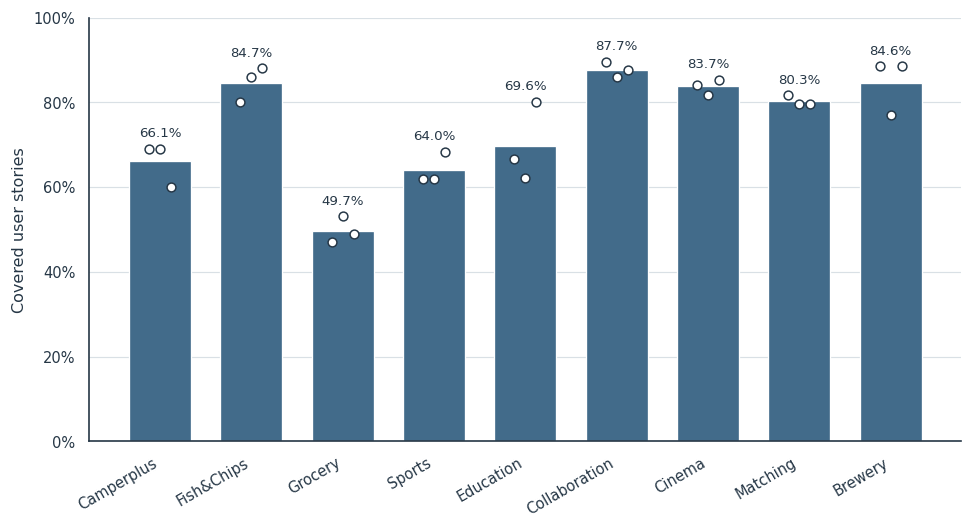

In [11]:
thesis_coverage_df = thesis_all_runs_df.dropna(subset=["coverage_score"]).copy()
thesis_coverage_df["coverage_percent"] = thesis_coverage_df["coverage_score"] * 100
thesis_coverage_means = (
    thesis_coverage_df.groupby("dataset", observed=True)["coverage_percent"]
    .mean()
    .reindex(THESIS_DATASET_ORDER)
)

fig, ax = plt.subplots(figsize=(8.2, 4.5))
x_positions = np.arange(len(THESIS_DATASET_ORDER))
ax.bar(
    x_positions,
    thesis_coverage_means.values,
    color=THESIS_BLUE,
    width=0.68,
    edgecolor="white",
    linewidth=0.8,
    zorder=2,
)

for index, dataset in enumerate(THESIS_DATASET_ORDER):
    values = thesis_coverage_df.loc[
        thesis_coverage_df["dataset"].astype(str) == dataset, "coverage_percent"
    ].to_numpy()
    offsets = np.linspace(-0.12, 0.12, len(values))
    ax.scatter(
        np.full(len(values), index) + offsets,
        values,
        s=28,
        facecolor="white",
        edgecolor=THESIS_DARK,
        linewidth=0.9,
        zorder=3,
    )
    ax.text(
        index,
        min(values.max() + 2.2, 97.0),
        f"{thesis_coverage_means.loc[dataset]:.1f}%",
        ha="center",
        va="bottom",
        fontsize=8,
        color=THESIS_DARK,
    )

ax.set_ylabel("Covered user stories")
ax.set_xlabel("")
ax.set_xticks(x_positions)
ax.set_xticklabels(
    [THESIS_DATASET_LABELS[name] for name in THESIS_DATASET_ORDER],
    rotation=30,
    ha="right",
)
thesis_finish_axis(ax, percent=True)
fig.tight_layout()
thesis_export_figure(fig, "story_coverage")
plt.show()


### Execution time

This plot shows the raw run values, the mean, and the full min-max range for each dataset. With only three runs per dataset, that makes the comparison easier to read than a boxplot with interpolated quartiles.

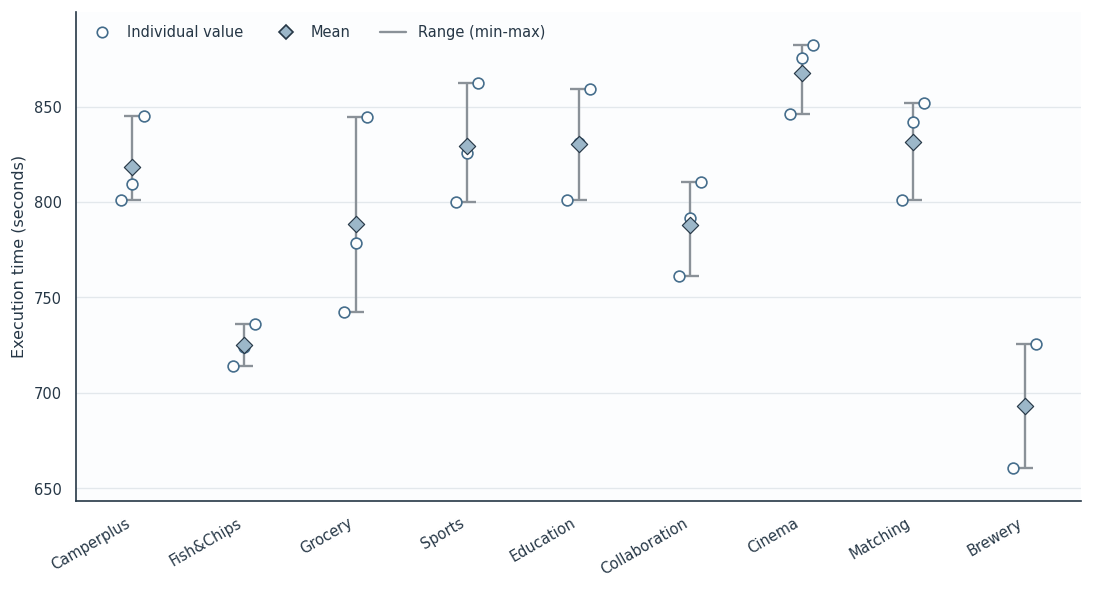

In [12]:
from matplotlib.lines import Line2D

thesis_runtime_df = thesis_all_runs_df.dropna(subset=["total_end_to_end_time_s"]).copy()
runtime_order = [THESIS_DATASET_LABELS[name] for name in THESIS_DATASET_ORDER]

fig, ax = plt.subplots(figsize=(9.2, 5.0))
ax.set_facecolor("#FCFDFE")
fig.patch.set_facecolor("white")
ax.set_axisbelow(True)
ax.grid(axis="y", color=THESIS_GRID, linewidth=0.8, alpha=0.7)
ax.grid(axis="x", visible=False)
for index, dataset in enumerate(THESIS_DATASET_ORDER):
    values = (
        thesis_runtime_df.loc[thesis_runtime_df["dataset"] == dataset, "total_end_to_end_time_s"]
        .dropna()
        .sort_values()
        .to_numpy()
    )
    if len(values) == 0:
        continue
    x_offsets = np.linspace(-0.10, 0.10, len(values)) if len(values) > 1 else np.array([0.0])
    xs = index + x_offsets
    ymin, ymax = float(values.min()), float(values.max())
    mean_value = float(values.mean())

    ax.vlines(index, ymin, ymax, color="#8A9198", linewidth=1.4, zorder=1)
    cap_half_width = 0.08
    ax.hlines([ymin, ymax], index - cap_half_width, index + cap_half_width, color="#8A9198", linewidth=1.4, zorder=1)
    ax.scatter(
        xs,
        values,
        s=42,
        facecolor="white",
        edgecolor=THESIS_BLUE,
        linewidth=1.0,
        alpha=0.98,
        zorder=3,
    )
    ax.scatter(
        [index],
        [mean_value],
        marker="D",
        s=48,
        facecolor=THESIS_LIGHT_BLUE,
        edgecolor=THESIS_DARK,
        linewidth=0.7,
        zorder=4,
    )

ax.set_xticks(np.arange(len(THESIS_DATASET_ORDER)))
ax.set_xticklabels(runtime_order, rotation=30, ha="right")
ax.set_ylabel("Execution time (seconds)")
ax.set_xlabel("")

ymin_all = thesis_runtime_df["total_end_to_end_time_s"].min()
ymax_all = thesis_runtime_df["total_end_to_end_time_s"].max()
pad = max(5.0, (ymax_all - ymin_all) * 0.08)
ax.set_ylim(max(0, ymin_all - pad), ymax_all + pad)

legend_handles = [
    Line2D([], [], linestyle="none", marker="o", markersize=6.3, markerfacecolor="white", markeredgecolor=THESIS_BLUE, label="Individual value"),
    Line2D([], [], linestyle="none", marker="D", markersize=6.0, markerfacecolor=THESIS_LIGHT_BLUE, markeredgecolor=THESIS_DARK, label="Mean"),
    Line2D([], [], color="#8A9198", linewidth=1.4, label="Range (min-max)"),
]
thesis_finish_axis(ax)
ax.legend(handles=legend_handles, frameon=False, loc="upper left", ncol=3, handlelength=1.8, columnspacing=2.0)
fig.tight_layout()
thesis_export_figure(fig, "execution_time")
plt.show()

### Descriptive statistics

The overview table retains relevant non-distributional context. Artifact quantities that were previously reported through means, standard deviations, minima, or maxima are shown as boxplot panels using the underlying run-level values.

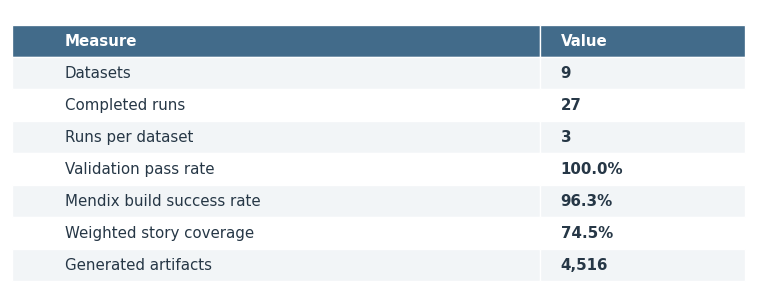

,Measure,Value
0,Datasets,9
1,Completed runs,27
2,Runs per dataset,3
3,Validation pass rate,100.0%
4,Mendix build success rate,96.3%
5,Weighted story coverage,74.5%
6,Generated artifacts,"4,516"


In [13]:
thesis_overview_rows = [
    ("Datasets", thesis_all_runs_df["dataset"].nunique()),
    ("Completed runs", len(thesis_all_runs_df)),
    ("Runs per dataset", int(thesis_all_runs_df.groupby("dataset", observed=True).size().median())),
    ("Validation pass rate", f"{thesis_all_runs_df['validation_passed'].mean() * 100:.1f}%"),
    ("Mendix build success rate", f"{thesis_all_runs_df['mendix_app_created'].mean() * 100:.1f}%"),
    ("Weighted story coverage", f"{thesis_all_runs_df['coverage_covered'].sum() / thesis_all_runs_df['coverage_total'].sum() * 100:.1f}%"),
    ("Generated artifacts", f"{int(thesis_all_runs_df['generated_artifact_count'].sum()):,}"),
]
thesis_overview_df = pd.DataFrame(thesis_overview_rows, columns=["Measure", "Value"])

fig, ax = plt.subplots(figsize=(6.4, 2.65))
ax.axis("off")
table = ax.table(
    cellText=thesis_overview_df.values,
    colLabels=thesis_overview_df.columns,
    cellLoc="left",
    colLoc="left",
    colWidths=[0.72, 0.28],
    loc="center",
)
table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(1, 1.38)
for (row, col), cell in table.get_celld().items():
    cell.set_edgecolor("white")
    if row == 0:
        cell.set_facecolor(THESIS_BLUE)
        cell.set_text_props(color="white", weight="bold")
    else:
        cell.set_facecolor("#F2F5F7" if row % 2 else "white")
        if col == 1:
            cell.set_text_props(weight="semibold")
fig.tight_layout()
thesis_export_figure(fig, "descriptive_overview_table")
plt.show()

display(thesis_overview_df)

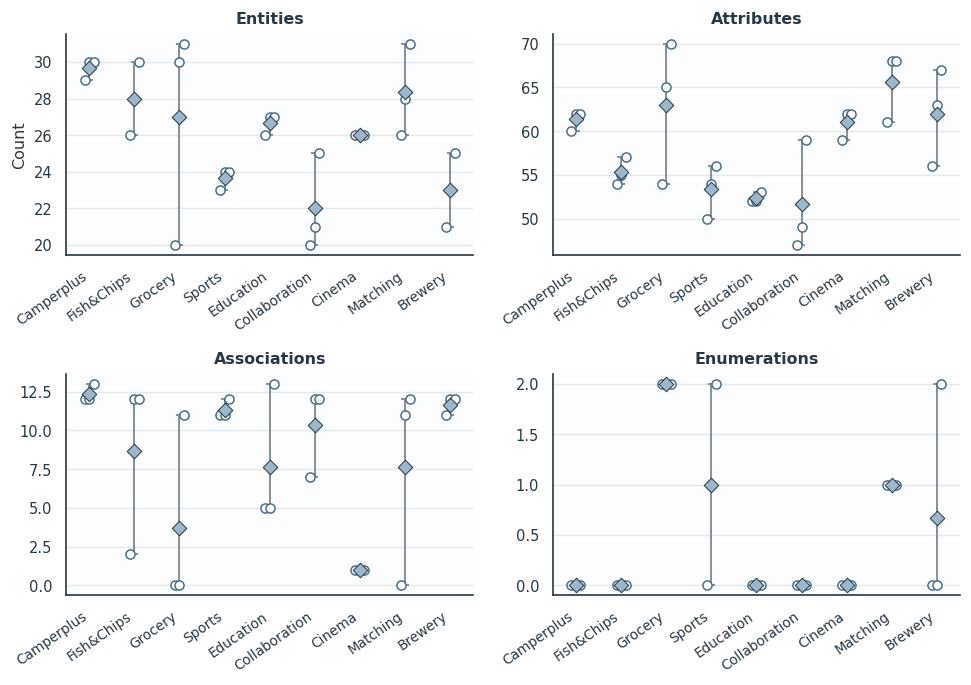

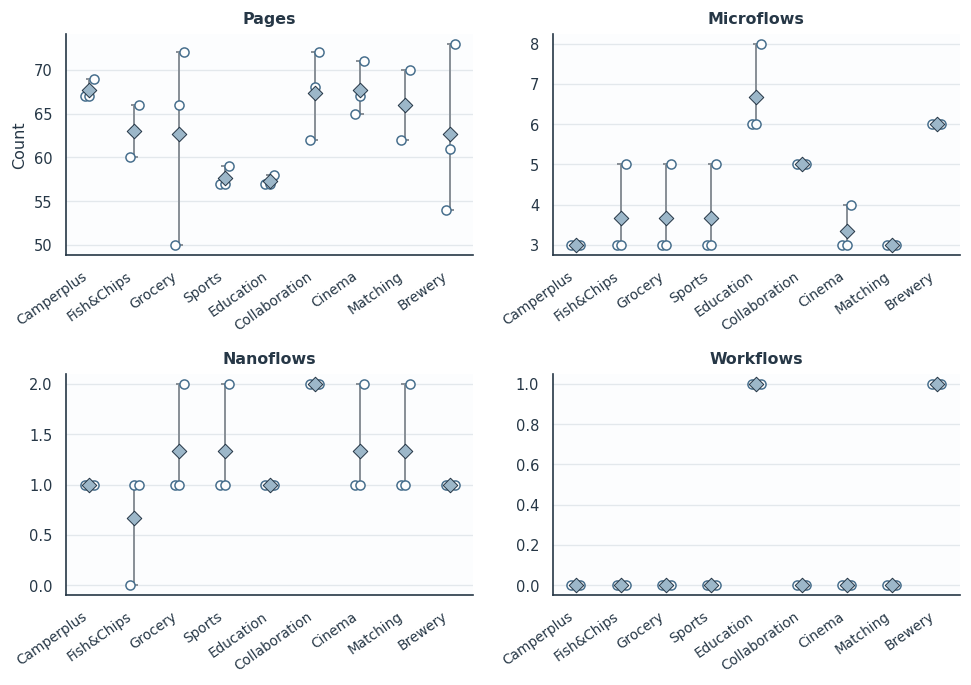

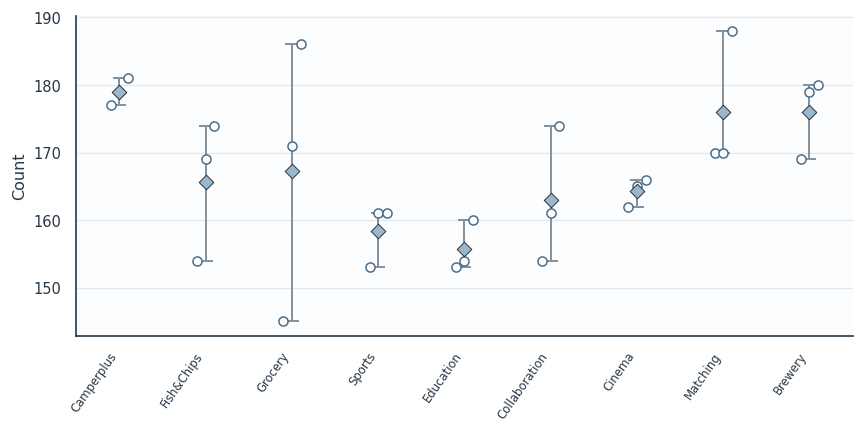

In [14]:
THESIS_ARTIFACT_METRICS = [
    ("entity_count", "Entities"),
    ("attribute_count", "Attributes"),
    ("association_count", "Associations"),
    ("enumeration_count", "Enumerations"),
    ("page_count", "Pages"),
    ("microflow_count", "Microflows"),
    ("nanoflow_count", "Nanoflows"),
    ("workflow_count", "Workflows"),
    ("security_role_count", "Security roles"),
    ("generated_artifact_count", "Total artifacts"),
]

thesis_artifact_long_df = thesis_all_runs_df.melt(
    id_vars=["dataset", "dataset_label", "run_id"],
    value_vars=[metric for metric, _ in THESIS_ARTIFACT_METRICS],
    var_name="metric",
    value_name="count",
)
metric_labels = dict(THESIS_ARTIFACT_METRICS)
thesis_artifact_long_df["metric_label"] = thesis_artifact_long_df["metric"].map(metric_labels)

metric_groups = [
    (
        "Domain-model artifacts",
        THESIS_ARTIFACT_METRICS[:4],
        "descriptive_artifact_counts_domain",
        (2, 2),
        (8.2, 5.8),
    ),
    (
        "Interface and logic artifacts",
        THESIS_ARTIFACT_METRICS[4:8],
        "descriptive_artifact_counts_interface_logic",
        (2, 2),
        (8.2, 5.8),
    ),
    (
        "Total generated artifacts",
        THESIS_ARTIFACT_METRICS[9:],
        "descriptive_artifact_counts_total",
        (1, 1),
        (7.3, 3.7),
    ),
]

for group_title, metrics, export_stem, grid_shape, figure_size in metric_groups:
    metric_names = [name for name, _ in metrics]
    group_df = thesis_artifact_long_df[thesis_artifact_long_df["metric"].isin(metric_names)]
    fig, axes = plt.subplots(
        *grid_shape,
        figsize=figure_size,
        squeeze=False,
        sharex=False,
    )
    axes = axes.ravel()

    for ax, (metric, label) in zip(axes, metrics):
        metric_df = group_df[group_df["metric"] == metric]
        metric_order = [THESIS_DATASET_LABELS[name] for name in THESIS_DATASET_ORDER]
        ax.set_facecolor("#FCFDFE")
        ax.set_axisbelow(True)
        ax.grid(axis="y", color=THESIS_GRID, linewidth=0.8, alpha=0.7)
        ax.grid(axis="x", visible=False)

        for index, dataset in enumerate(THESIS_DATASET_ORDER):
            values = (
                metric_df.loc[metric_df["dataset"] == dataset, "count"]
                .dropna()
                .sort_values()
                .to_numpy()
            )
            if len(values) == 0:
                continue
            x_offsets = np.linspace(-0.10, 0.10, len(values)) if len(values) > 1 else np.array([0.0])
            xs = index + x_offsets
            ymin, ymax = float(values.min()), float(values.max())
            mean_value = float(values.mean())

            ax.vlines(index, ymin, ymax, color="#8A9198", linewidth=1.2, zorder=1)
            cap_half_width = 0.08
            ax.hlines([ymin, ymax], index - cap_half_width, index + cap_half_width, color="#8A9198", linewidth=1.2, zorder=1)
            ax.scatter(
                xs,
                values,
                s=30,
                facecolor="white",
                edgecolor=THESIS_BLUE,
                linewidth=0.9,
                alpha=0.98,
                zorder=3,
            )
            ax.scatter(
                [index],
                [mean_value],
                marker="D",
                s=38,
                facecolor=THESIS_LIGHT_BLUE,
                edgecolor=THESIS_DARK,
                linewidth=0.6,
                zorder=4,
            )
        if len(metrics) > 1:
            ax.set_title(label, fontsize=9.5)
        ax.set_ylabel("Count" if ax is axes[0] else "")
        ax.set_xlabel("")
        label_rotation = 35 if len(metrics) > 1 else 55
        label_size = 8.2 if len(metrics) > 1 else 7
        ax.set_xticks(np.arange(len(THESIS_DATASET_ORDER)))
        ax.set_xticklabels(metric_order, rotation=label_rotation, fontsize=label_size, ha="right")
        thesis_finish_axis(ax)

    for unused_ax in axes[len(metrics):]:
        unused_ax.remove()

    fig.tight_layout(h_pad=1.2, w_pad=1.5)
    thesis_export_figure(fig, export_stem)
    plt.show()
